# Bike Sharing Assignment

## Problem statement:

Build a multiple linear regression model for the prediction of demand for shared bikes

The company wants to know:

1. Which variables are significant in predicting the demand for shared bikes.
2. How well those variables describe the bike demands

## Step 1: Reading and Understanding the Data

Let us first import NumPy and Pandas and read the Bike data

In [24]:
# Supress Warnings

import warnings
warnings.filterwarnings('ignore')

In [25]:
#Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from sklearn.metrics import r2_score

In [26]:
# reading the dataset provided
bike = pd.read_csv("day.csv")

In [27]:
#Understanding the data 

bike.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


In [28]:
bike.shape

(730, 16)

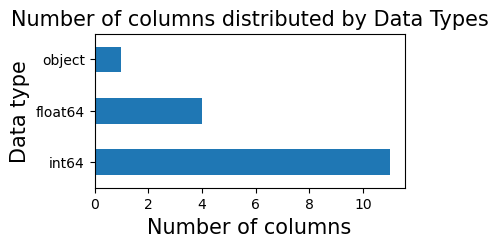

In [29]:
#Visualize the distribution of datatypes in dataset
plt.figure(figsize = (4,2))
bike.dtypes.value_counts().plot(kind='barh')
plt.title('Number of columns distributed by Data Types',fontsize=15)
plt.xlabel('Number of columns',fontsize=15)
plt.ylabel('Data type',fontsize=15)
plt.show()

In [30]:
bike.info()

# Obs: No missing values 
#Obs: A few variables needs to be changed to categorical variable for better analysis later.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   dteday      730 non-null    object 
 2   season      730 non-null    int64  
 3   yr          730 non-null    int64  
 4   mnth        730 non-null    int64  
 5   holiday     730 non-null    int64  
 6   weekday     730 non-null    int64  
 7   workingday  730 non-null    int64  
 8   weathersit  730 non-null    int64  
 9   temp        730 non-null    float64
 10  atemp       730 non-null    float64
 11  hum         730 non-null    float64
 12  windspeed   730 non-null    float64
 13  casual      730 non-null    int64  
 14  registered  730 non-null    int64  
 15  cnt         730 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.4+ KB


In [31]:
# Understanding the central tendency of varaibles in data 
bike.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,365.500000,2.498630,0.500000,6.526027,0.028767,2.997260,0.683562,1.394521,20.319259,23.726322,62.765175,12.763620,849.249315,3658.757534,4508.006849
std,210.877136,1.110184,0.500343,3.450215,0.167266,2.006161,0.465405,0.544807,7.506729,8.150308,14.237589,5.195841,686.479875,1559.758728,1936.011647
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.424346,3.953480,0.000000,1.500244,2.000000,20.000000,22.000000
25%,183.250000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,13.811885,16.889713,52.000000,9.041650,316.250000,2502.250000,3169.750000
50%,365.500000,3.000000,0.500000,7.000000,0.000000,3.000000,1.000000,1.000000,20.465826,24.368225,62.625000,12.125325,717.000000,3664.500000,4548.500000
75%,547.750000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,26.880615,30.445775,72.989575,15.625589,1096.500000,4783.250000,5966.000000
max,730.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,35.328347,42.044800,97.250000,34.000021,3410.000000,6946.000000,8714.000000


In [32]:
#Rename the column names for better understanding

bike.rename(columns = {'yr':'Year','mnth':'month','hum':'humidity','cnt':'count'}, inplace = True) 
bike.head()

,instant,dteday,season,Year,month,holiday,weekday,workingday,weathersit,temp,atemp,humidity,windspeed,casual,registered,count
0,1,01-01-2018,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


In [33]:
#Converting a few numrical variables into categorical variables like season, month, weathersit, weekday, Year and holiday

bike['season']=bike.season.map({1: 'spring', 2: 'summer',3:'fall', 4:'winter' })
bike['month']=bike.month.map({1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'June',7:'July',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'})
bike['weathersit']=bike.weathersit.map({1: 'Clear',2:'Mist + Cloudy',3:'Light Snow',4:'Snow + Fog'})
bike['weekday']=bike.weekday.map({0:'Sun',1:'Mon',2:'Tue',3:'Wed',4:'Thu',5:'Fri',6:'Sat'})

In [34]:
bike.head()

,instant,dteday,season,Year,month,holiday,weekday,workingday,weathersit,temp,atemp,humidity,windspeed,casual,registered,count
0,1,01-01-2018,spring,0,Jan,0,Sat,0,Mist + Cloudy,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,spring,0,Jan,0,Sun,0,Mist + Cloudy,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,spring,0,Jan,0,Mon,1,Clear,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,spring,0,Jan,0,Tue,1,Clear,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,spring,0,Jan,0,Wed,1,Clear,9.305237,11.46350,43.6957,12.522300,82,1518,1600


# Step 2: Visualising the data

## Visualising numerical variables

### Multivariate Analysis

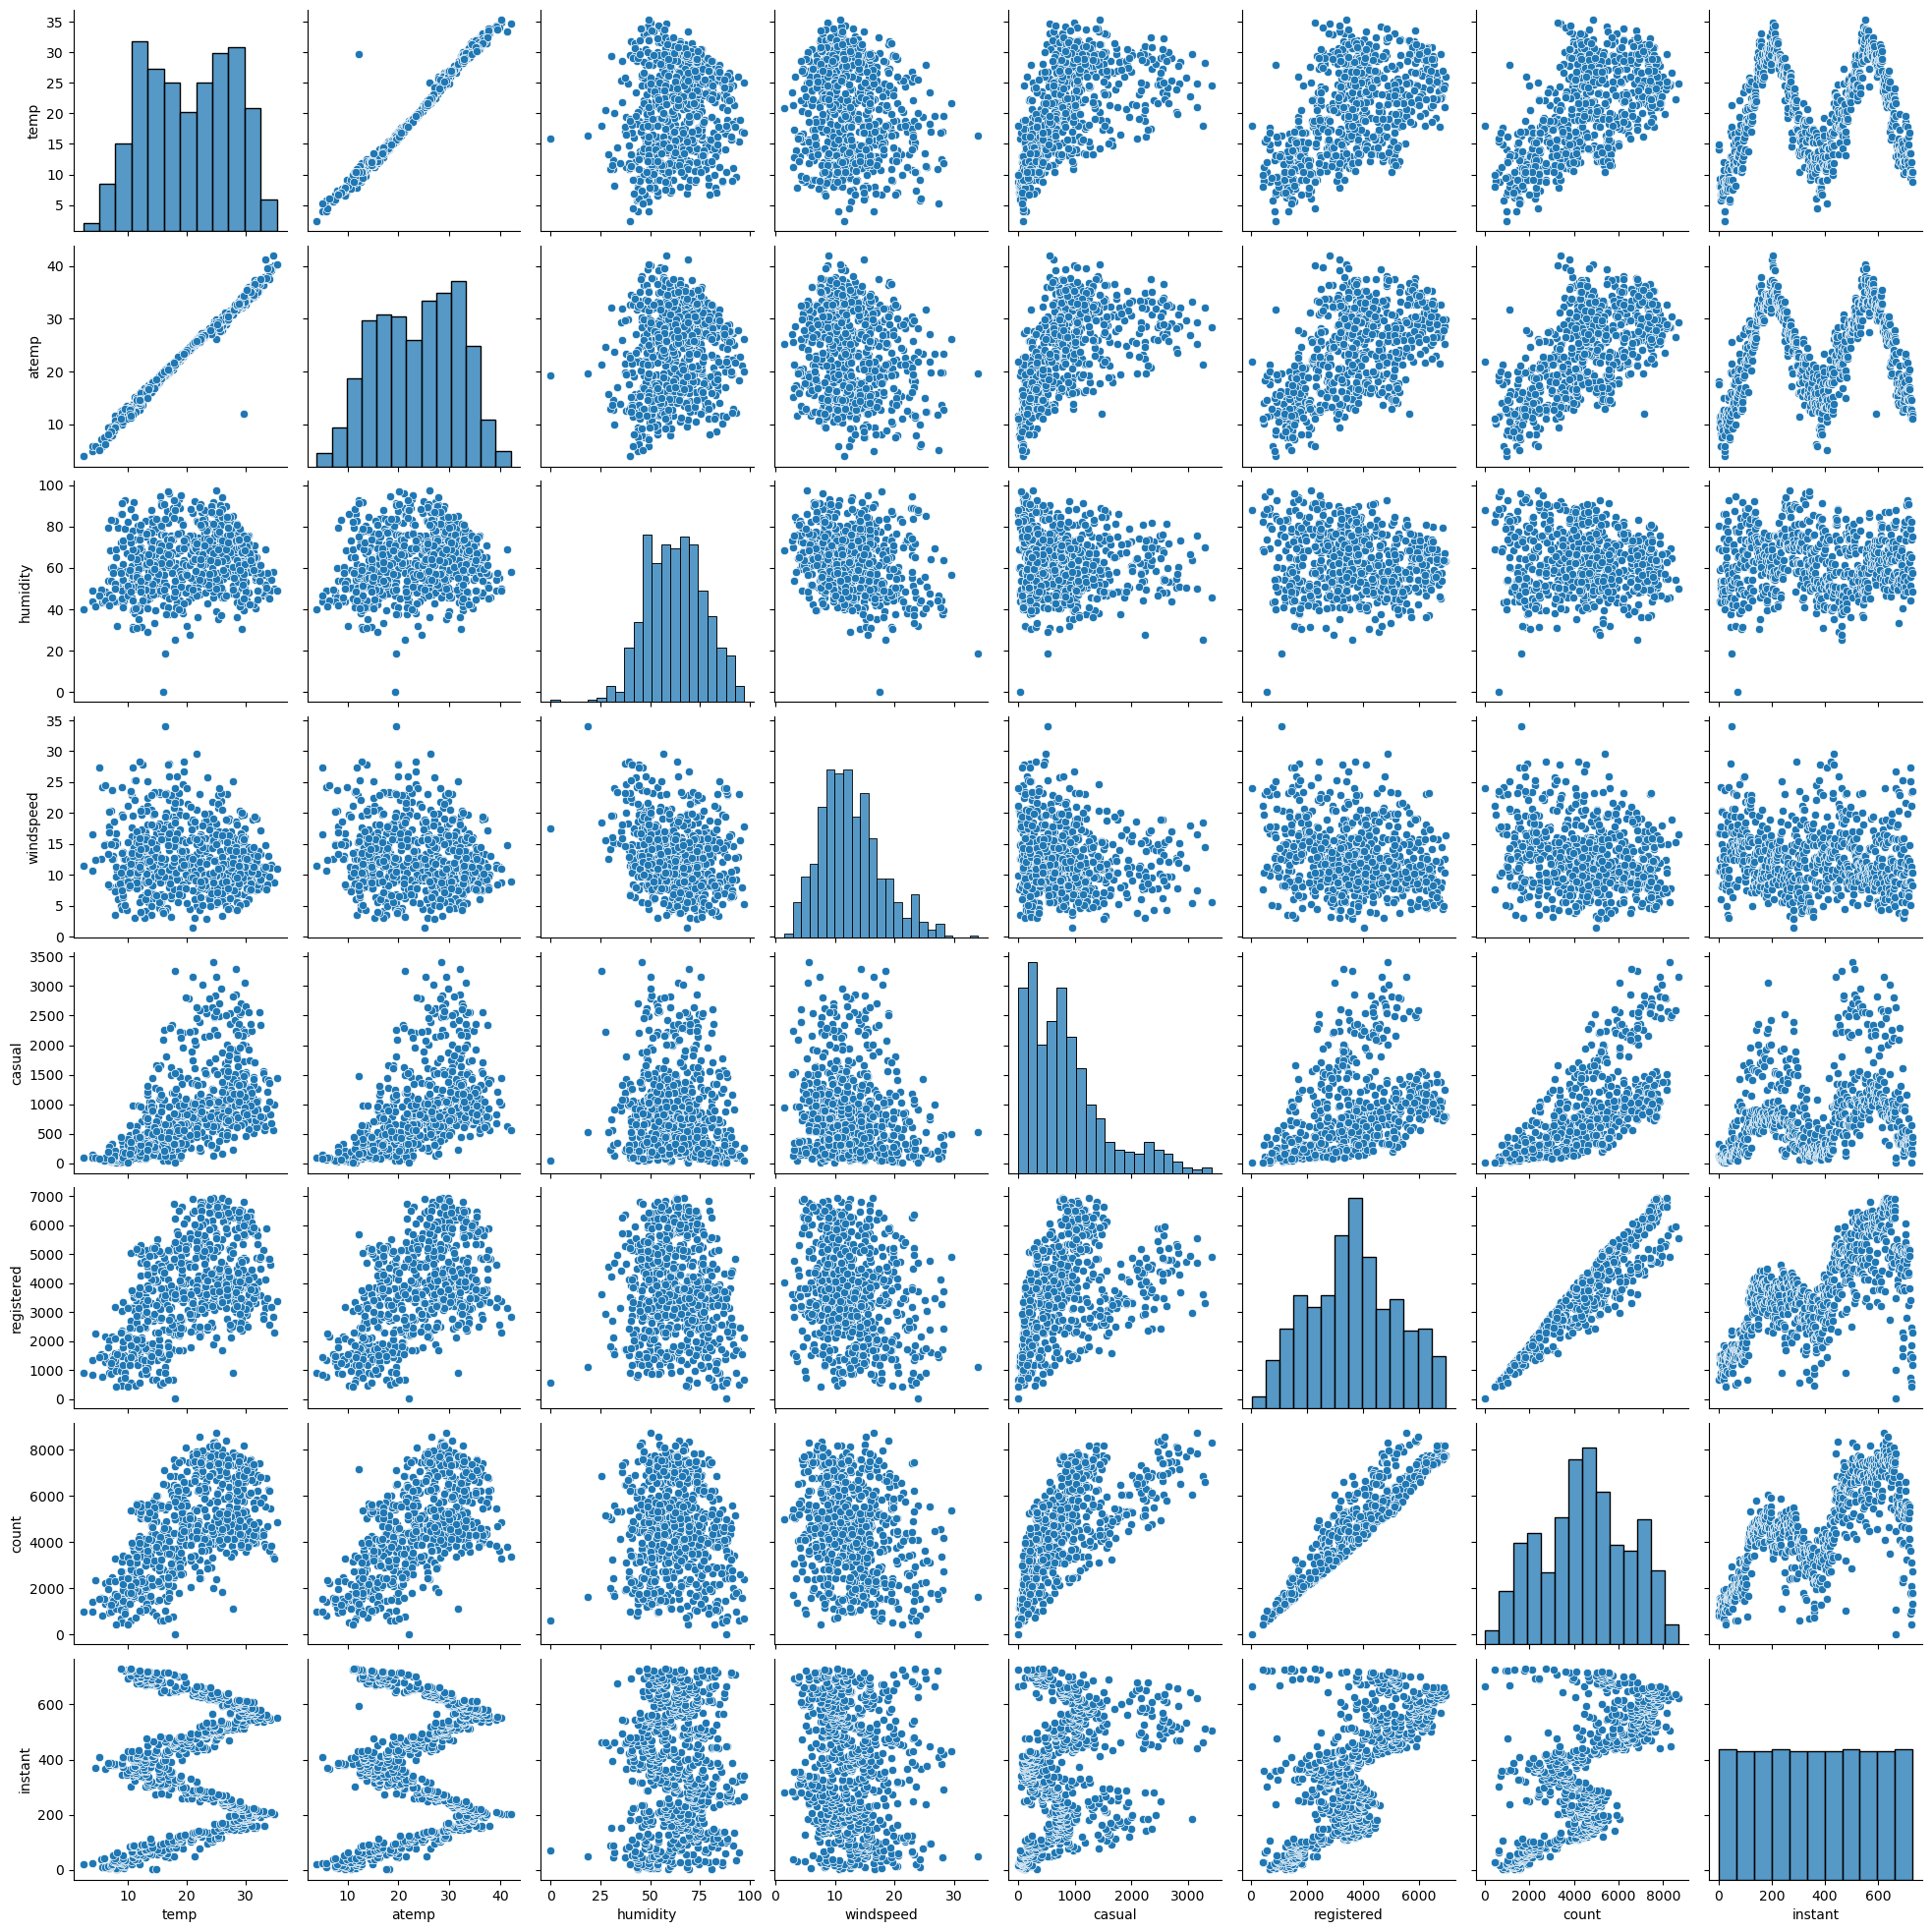

In [35]:
#Pairplot for all numerical plot to see if correlation is present clearly between few variables

sns.pairplot(data = bike, vars= ['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered','count', 'instant'])
plt.show()

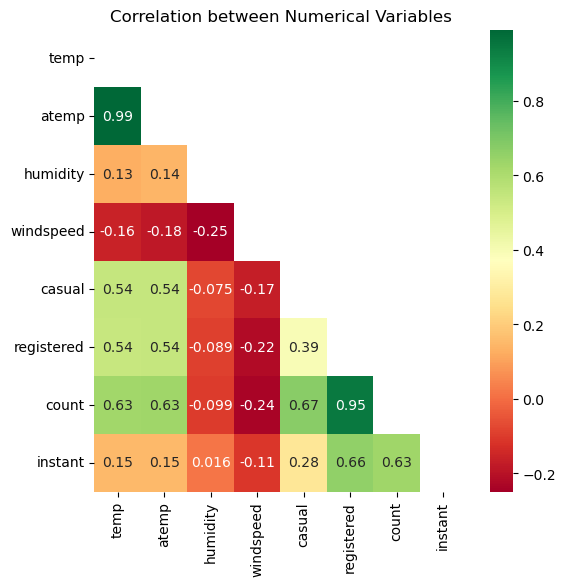

In [36]:
#heatmap to see clear correlation between variables
#plt.figure(figsize = (15,8))
#sns.heatmap(bike.corr(), cmap = 'YlGnBu', annot = True)
#plt.show()

plt.figure(figsize = (6,6))
matrix = np.triu(bike[['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered','count', 'instant']].corr())
sns.heatmap(bike[['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered','count', 'instant']].corr(), annot = True, cmap="RdYlGn", mask=matrix)
plt.title("Correlation between Numerical Variables")
plt.show()

#Obs: It can be seen that count is highly correlated with registered, casual, temp, atemp, instant variables

### Bivariate Analysis

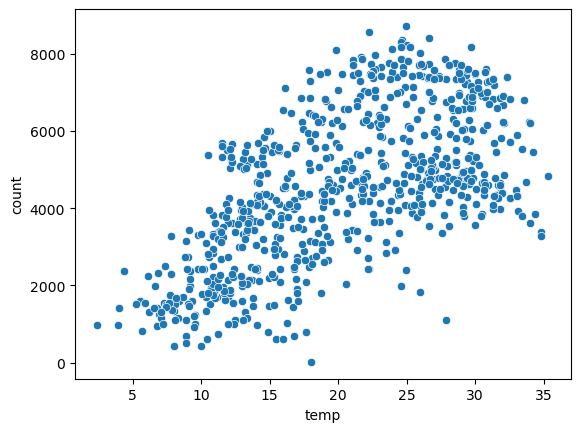

In [37]:
#scatter plot for temperature and count
sns.scatterplot(x='temp',y='count' ,data=bike)
plt.show()

#Temperature and count seems to be positively correlated

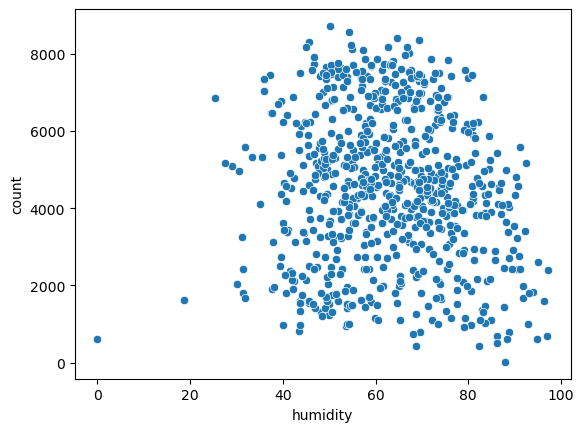

In [38]:
#scatter plot for relationship between humidity and count
sns.scatterplot(x='humidity', y='count',data=bike)
plt.show()

#HUmidity and count negatively correlated

## Visualising categorical variables

### Bivariate Analysis

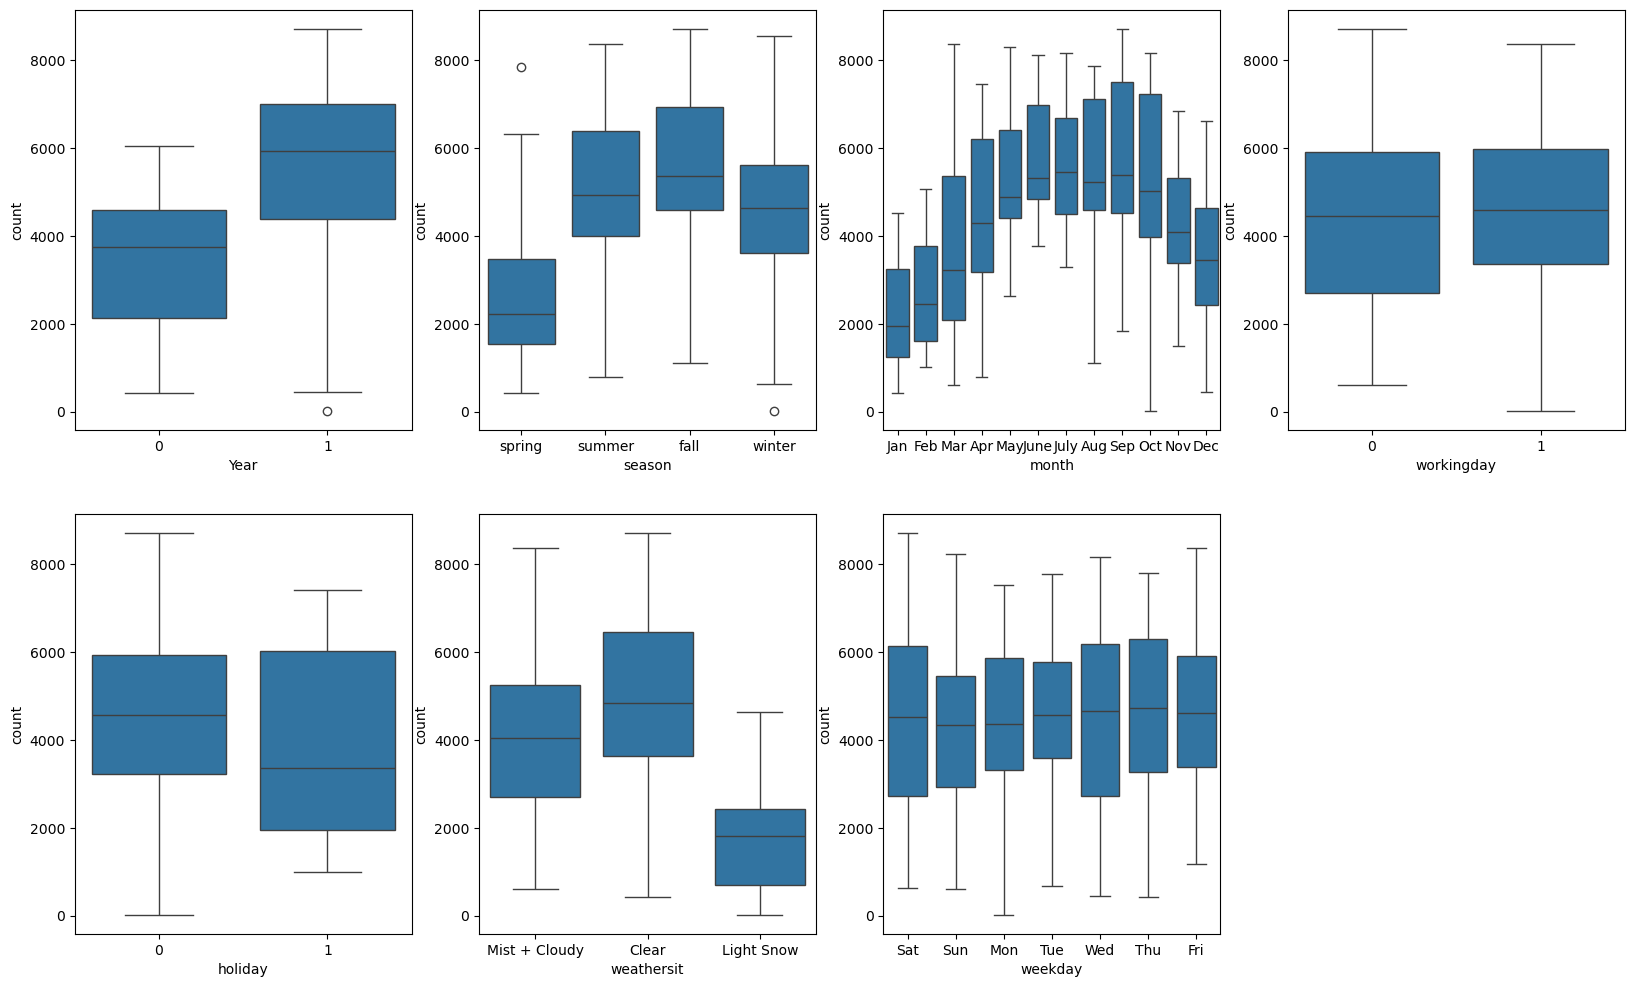

In [39]:
plt.figure(figsize = (20,12))
plt.subplot(2,4,1)
sns.boxplot(x = 'Year', y = 'count', data = bike)
plt.subplot(2,4,2)
sns.boxplot(x = 'season', y = 'count', data = bike)
plt.subplot(2,4,3)
sns.boxplot(x = 'month', y = 'count', data = bike)
plt.subplot(2,4,4)
sns.boxplot(x = 'workingday', y = 'count', data = bike)
plt.subplot(2,4,5)
sns.boxplot(x = 'holiday', y = 'count', data = bike)
plt.subplot(2,4,6)
sns.boxplot(x = 'weathersit', y = 'count', data = bike)
plt.subplot(2,4,7)
sns.boxplot(x = 'weekday', y = 'count', data = bike)
plt.show()

#Obs: The plots above shows the relationship between categorical variables and a Target variable (count)
#Bike Rentals are more in the year 2019 compared to 2018
#Bike Rentals are more during the Fall season and then in summer
#Bike Rentals are more in partly cloudy weather
#Bike Rentals are more on Saturday,wednesday and thursday

### Univariate analysis

In [40]:
#Barplot to see relation between season and count of bike rentals
sns.barplot('season','count',data=bike,palette="rocket",)
plt.show()

# Obs: Count has increased most for fall season

TypeError: barplot() got multiple values for argument 'data'

In [ ]:
#Relation between weather and count of bike rentals
sns.barplot('weathersit','count',palette="muted",data=bike)
plt.show()

#Obs: Count is most impacted in Clear weather

In [ ]:
#Relation between Year and count of bike rentals
sns.barplot('Year','count',data=bike)
plt.show()

# Count is increased year on year 

In [ ]:
#Relation between month and count
plt.figure(figsize=(10,5))
sns.barplot('month','count',hue='Year',data=bike,palette='Paired')
plt.show()

# Count remains less in beginning and end of year

## Drop the columns which are not adding any value

In [ ]:
#Dropping instant as it is unique identier and will not add value further
#Dropping dteday as we already have year, month and season to predict 
#Dropping atemp as it is closely correlated with temp and will lead to multicolliearity later while building model
#Dropping casual and registered as we have to considered sum of both - 'Count' as target variable

bike= bike.drop(['instant','dteday','casual', 'registered','atemp'], axis=1)
bike.head()

## Step 3: Data Preparation

Dummy Variable Encoding

In [ ]:
#Creating dummy variables and concatenating them with dataset

season = pd.get_dummies(bike.season, drop_first = True)
month = pd.get_dummies(bike.month, drop_first = True)
weekday = pd.get_dummies(bike.weekday, drop_first = True)
weather_sit = pd.get_dummies(bike.weathersit, drop_first = True)

bike = pd.concat([bike, season, month, weekday, weather_sit], axis = 1)

#dropping variables which are duplicate of dummy variables

bike.drop(['season', 'month', 'weekday', 'weathersit'], axis = 1, inplace = True)

In [ ]:
bike.head()

# Step 4: Splitting Dataset into test and training dataset

In [ ]:
#import relevant libraries and classes 

import sklearn
from sklearn.model_selection import train_test_split

In [ ]:
#split the dataset
bike_train, bike_test = train_test_split (bike, train_size=0.7, random_state =100)

In [ ]:
bike_train.shape

In [ ]:
bike_test.shape

# Step 5: Rescaling variables using min max scaling 

In [ ]:
#importing relevant library (for min max scaling)
from sklearn.preprocessing import MinMaxScaler

In [ ]:
#Instantiate an object
scaler= MinMaxScaler()

In [ ]:
# Scaling the numerical variables
num_vars = ['temp', 'humidity', 'windspeed', 'count']
bike_train[num_vars] = scaler.fit_transform(bike_train[num_vars])
bike_train.describe()

In [ ]:
# Plotting heatmap to see correlations among variables after scaling
plt.figure(figsize = (25,10))
sns.heatmap(bike_train.corr(), annot = True, cmap = 'YlGnBu')

# Obs: year and temperature is strongly positively correlated with count with r values of 0.59 and 0.65 respectively.  

In [ ]:
#Divide the X (predict) and Y (target) variables to create model

y_train = bike_train.pop("count")
X_train= bike_train

# Step 6: Model Building (Build the linear model)

Using RFE (Recursive Feature elimnation) method

In [ ]:
#importing relevant package & class

from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

In [ ]:
X_train.shape

In [ ]:
#Fit the model
lm = LinearRegression()
lm.fit(X_train, y_train)

#Provide the number of features as 15 and run RFE
rfe = RFE(lm,15)
rfe = rfe.fit(X_train, y_train)

In [ ]:
# Variables which are part of 15 features in the model and rated them as per priority
list(zip(X_train.columns, rfe.support_, rfe.ranking_))

In [ ]:
#All columns which are selected by RFE model for 15 variables 
col = X_train.columns[rfe.support_]
col

#Obs: Below are the variables selected by RFE method. These variables have relatively high importance or impact on count variable

In [ ]:
#All columns which are not part of that 15 variables
X_train.columns[~rfe.support_]

#Obs: These variables relatively have less or no importance on count variable

## Building model using statsmodel, for the detailed statistics

In [ ]:
# Creating X_test dataframe with RFE selected variables
X_train_rfe = X_train[col]

In [ ]:
#adding a constant variable to statsmodels
import statsmodels.api as sm
X_train_rfe = sm.add_constant(X_train_rfe)

In [ ]:
# Running the linear model 
lr = sm.OLS(y_train , X_train_rfe).fit()

In [ ]:
lr.summary()

In [ ]:
#Dropping constant in the model
X_train_rfe = X_train_rfe.drop(['const'], axis=1)

#Calculate VIF for this model to determine multicollinearity

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
X = X_train_rfe
vif['Features'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
vif['VIF'] = round(vif['VIF'],2)
vif = vif.sort_values(by = 'VIF', ascending = False)
vif

In [ ]:
#Drop holiday due to high p value =0.806
X_train_new1 = X_train_rfe.drop(["holiday"], axis = 1)

In [ ]:
#Build a model
X_train_lm1 = sm.add_constant(X_train_new1)
lm1 = sm.OLS(y_train,X_train_lm1).fit()
print(lm1.summary())

In [ ]:
#Drop the constant term B0
X_train_lm1 = X_train_lm1.drop(['const'], axis=1)

In [ ]:
# Calculate the VIFs for the new model to determine multicollinearity
vif = pd.DataFrame()
X = X_train_new1
vif['Features'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

In [ ]:
#Removing 'humidity' due to high VIF =29.73

X_train_new2 = X_train_lm1.drop(["humidity"], axis = 1)

In [ ]:
#Build a model

X_train_lm2 = sm.add_constant(X_train_new2)
lm2 = sm.OLS(y_train,X_train_lm2).fit()
print(lm2.summary())

In [ ]:
#Drop the constant
X_train_lm2=X_train_lm2.drop(['const'], axis=1)

In [ ]:
# Calculate the VIFs for the new model to determine multicollinearity
vif = pd.DataFrame()
X = X_train_new2
vif['Features'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

In [ ]:
#Drop the workingday column due to high VIF = 13.48
X_train_new3=X_train_lm2.drop(['workingday'],axis=1)

In [ ]:
# Adding a constant variable 
X_train_lm3 = sm.add_constant(X_train_new3)
lm3 = sm.OLS(y_train,X_train_lm3).fit()
print(lm3.summary())

In [ ]:
#Drop constant 
X_train_lm3=X_train_lm3.drop(['const'],axis=1)

In [ ]:
# Calculate the VIFs for the new model to determine multicollinearity
vif = pd.DataFrame()
X = X_train_new3
vif['Features'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

In [ ]:
#Drop Sat due to high p value =0.175
X_train_new4= X_train_lm3.drop(['Sat'], axis=1)

In [ ]:
#Build a model
X_train_lm4=sm.add_constant(X_train_new4)
lm4=sm.OLS(y_train,X_train_lm4).fit()
print(lm4.summary())

In [ ]:
#Drop constant
X_train_lm4= X_train_lm4.drop(['const'], axis=1)

In [ ]:
# Calculate the VIFs for the new model to determine multicollinearity
vif = pd.DataFrame()
X =X_train_new4
vif['Features'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

Obs: We reached a stage where p value is less than 0.05 and VIF is less than 5. We can go forward with these variables. If we reduce the variables further like 'Jan' on the basis of VIF then the R2 starts dipping.

## Step 7: Residual Analysis of the train data

So, now to check if the error terms are also normally distributed (which is infact, one of the major assumptions of linear regression), let us plot the histogram of the error terms and see what it looks like.

In [ ]:
X_train_lm4.columns

In [ ]:
X_train_lm4=sm.add_constant(X_train_lm4)
X_train_lm4.columns

In [ ]:
#y train predicted
y_train_pred = lm4.predict(X_train_lm4)

In [ ]:
# Plot the histogram of the error terms

fig = plt.figure()
plt.figure(figsize=(10,5))
sns.distplot((y_train - y_train_pred), bins = 20)
plt.title('Error Terms', fontsize = 20)                  # Plot heading 
plt.xlabel('Errors', fontsize = 18)  # X-label
plt.show()

#Obs: We see that error terms are normally distributed

# Step 8: Making Predictions

In [ ]:
#Create a list of numeric variables
num_vars=['temp','humidity','windspeed','count']

#Fit on data
bike_test[num_vars] = scaler.transform(bike_test[num_vars])
bike_test.head()

We can see that the equation of our best fitted line is:

In [ ]:
#Dividing into X_test and y_test
y_test = bike_test.pop('count')
X_test = bike_test
X_test.describe()

In [ ]:
#Columns
X_train_new4.columns

In [ ]:
# Now let's use our model to make predictions.

# Creating X_test_new dataframe by dropping variables from X_test
X_test_new = X_test[X_train_new4.columns]
X_test_new.columns

In [ ]:
#Adding a const variable

X_test_new = sm.add_constant(X_test_new)

In [ ]:
#Maling predictions

y_pred = lm4.predict(X_test_new)

# Step 9 : Model Evaluation

In [ ]:
#Finding R-squared for Test set

#Evaluate R-square for test
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

In [ ]:
# Plotting y_test and y_pred to understand the spread.
plt.figure(figsize=(10,5))
plt.scatter(y_test,y_pred,color='blue')
fig.suptitle('y_test vs y_pred', fontsize=20)              # Plot heading 
plt.xlabel('y_test', fontsize=18)                          # X-label
plt.ylabel('y_pred', fontsize=16) 
plt.show()

# Step 10: Regression Equation

Count  = 0.273 + 0.235 *Year + 0.430 *temp - 0.149 *windspeed - 0.104 *spring + 0.039 *winter - 0.044 *Jan - 0.066 *July + 0.053 *Sep - 0.044 *Sun - 0.2873 *Light Snow - 0.078 *Mist + Cloudy